In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf

In [2]:
#Black_Scholes_OneDimension
class blackscholesmodel:
    def __init__(self,S,X,t,r,sigma):
        self.S = S
        self.X = X
        self.t = t
        self.r = r
        self.sigma = sigma
    def d1(self):
        return (np.log(self.S / self.X) + (self.r + 0.5 * (self.sigma ** 2)) * self.t) / (self.sigma * np.sqrt(self.t))
    def d2(self):
        return self.d1() - (self.sigma * np.sqrt(self.t))
    def call_price(self):
        return (self.S * norm.cdf(self.d1(), 0, 1) - self.X * np.exp(-self.r * self.t) * norm.cdf(self.d2(), 0, 1))
    def put_price(self):
        return (self.X * np.exp(-self.r * self.t) * norm.cdf(-self.d2(), 0, 1) - self.S * norm.cdf(-self.d1(), 0, 1))

In [3]:
call_price = blackscholesmodel(100,110,1,0.05,0.25).call_price()
print(call_price)

8.026384693853352


Call: $5.9885
Put:  $8.3960
IV from $5.50 call: 23.27%


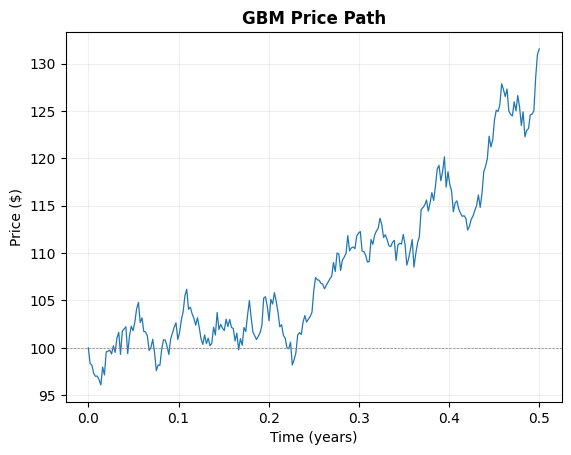

In [4]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


class blackscholesmodel:
    def __init__(self, S, X, t, r, sigma):
        self.S = S
        self.X = X
        self.t = t
        self.r = r
        self.sigma = sigma

    def d1(self):
        return (np.log(self.S / self.X) + (self.r + 0.5 * (self.sigma ** 2)) * self.t) / (self.sigma * np.sqrt(self.t))

    def d2(self):
        return self.d1() - (self.sigma * np.sqrt(self.t))

    def call_price(self):
        return (self.S * norm.cdf(self.d1(), 0, 1) - self.X * np.exp(-self.r * self.t) * norm.cdf(self.d2(), 0, 1))

    def put_price(self):
        return (self.X * np.exp(-self.r * self.t) * norm.cdf(-self.d2(), 0, 1) - self.S * norm.cdf(-self.d1(), 0, 1))

    def greeks(self, option_type="call"):
        d1, d2 = self.d1(), self.d2()
        sqrt_t = np.sqrt(self.t)
        gamma = norm.pdf(d1) / (self.S * self.sigma * sqrt_t)
        vega  = self.S * norm.pdf(d1) * sqrt_t / 100
        if option_type == "call":
            delta = norm.cdf(d1)
            theta = (-(self.S * self.sigma * norm.pdf(d1)) / (2 * sqrt_t)
                     - self.r * self.X * np.exp(-self.r * self.t) * norm.cdf(d2)) / 365
            rho   = self.X * self.t * np.exp(-self.r * self.t) * norm.cdf(d2) / 100
        else:
            delta = norm.cdf(d1) - 1
            theta = (-(self.S * self.sigma * norm.pdf(d1)) / (2 * sqrt_t)
                     + self.r * self.X * np.exp(-self.r * self.t) * norm.cdf(-d2)) / 365
            rho   = -self.X * self.t * np.exp(-self.r * self.t) * norm.cdf(-d2) / 100
        return {"delta": delta, "gamma": gamma, "theta": theta, "vega": vega, "rho": rho}

    def implied_vol(self, market_price, option_type="call", tol=1e-8, max_iter=200):
        sig = 0.3
        for _ in range(max_iter):
            temp = blackscholesmodel(self.S, self.X, self.t, self.r, sig)
            price = temp.call_price() if option_type == "call" else temp.put_price()
            vega_raw = self.S * norm.pdf(temp.d1()) * np.sqrt(self.t)
            if abs(vega_raw) < 1e-14:
                break
            diff = price - market_price
            if abs(diff) < tol:
                return sig
            sig -= diff / vega_raw
            sig = max(0.0001, min(sig, 10.0))
        return sig

    def simulate(self, N=252, num_paths=1, seed=None):
        """GBM simulation: returns (t_array, price_paths)"""
        if seed is not None:
            np.random.seed(seed)
        dt = self.t / N
        t = np.linspace(0, self.t, N + 1)
        dW = np.random.normal(0, np.sqrt(dt), size=(num_paths, N))
        log_S = np.zeros((num_paths, N + 1))
        log_S[:, 1:] = np.cumsum((self.r - 0.5 * self.sigma**2) * dt + self.sigma * dW, axis=1)
        S = self.S * np.exp(log_S)
        return t, S

    def plot_gbm(self, N=252, num_paths=1, seed=None):
        t, S = self.simulate(N, num_paths, seed)
        for i in range(num_paths):
            plt.plot(t, S[i], linewidth=0.9)
        plt.axhline(self.S, color="gray", linewidth=0.5, linestyle="--")
        plt.title("GBM Price Path", fontweight="bold")
        plt.xlabel("Time (years)")
        plt.ylabel("Price ($)")
        plt.grid(alpha=0.2)
        plt.show()


# ── Usage ──

model = blackscholesmodel(S=100, X=105, t=0.5, r=0.05, sigma=0.25)

print(f"Call: ${model.call_price():.4f}")
print(f"Put:  ${model.put_price():.4f}")
print(f"IV from $5.50 call: {model.implied_vol(5.50, 'call')*100:.2f}%")

model.plot_gbm()

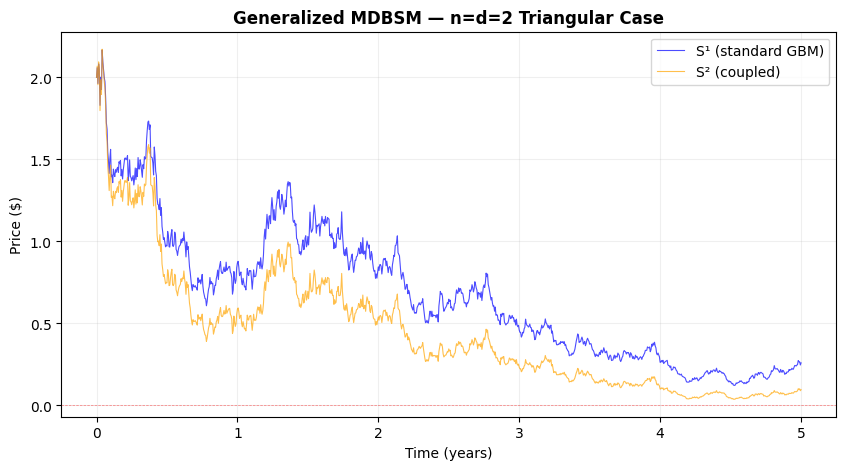

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class MDBSM:
    def __init__(self, x1_0, x2_0, mu1, mu2, b1, b2, b21_1, b21_2, T, N=1000):
        self.x1_0  = x1_0
        self.x2_0  = x2_0
        self.mu1   = mu1
        self.mu2   = mu2
        self.b1    = b1
        self.b2    = b2
        self.b21_1 = b21_1
        self.b21_2 = b21_2
        self.T     = T
        self.N     = N
        self.dt    = T / N
        self.t     = np.linspace(0, T, N + 1)

    def _check_nonarbitrage(self):
        """det[[b1, b2], [b21_1, b21_2]] != 0"""
        det = self.b1 * self.b21_2 - self.b2 * self.b21_1
        if abs(det) < 1e-12:
            print("WARNING: volatility matrix is singular — arbitrage possible")
        return det

    def simulate(self):
        dt = self.dt
        sqrt_dt = np.sqrt(dt)

        dW1 = np.random.normal(0, sqrt_dt, self.N)
        dW2 = np.random.normal(0, sqrt_dt, self.N)

        # S1: exact GBM solution
        sigma_sq = self.b1**2 + self.b2**2
        cum_W1 = np.concatenate([[0], np.cumsum(dW1)])
        cum_W2 = np.concatenate([[0], np.cumsum(dW2)])

        S1 = self.x1_0 * np.exp(
            (self.mu1 - 0.5 * sigma_sq) * self.t
            + self.b1 * cum_W1
            + self.b2 * cum_W2
        )

        S2 = np.zeros(self.N + 1)
        S2[0] = self.x2_0
        stopped = False

        for i in range(self.N):
            if stopped:
                S2[i + 1] = 0
                continue

            drift = self.mu2 * S2[i]
            diff1 = (self.b21_1 * S1[i] + self.b1 * S2[i]) * dW1[i]
            diff2 = (self.b21_2 * S1[i] + self.b2 * S2[i]) * dW2[i]

            S2[i + 1] = S2[i] + drift * dt + diff1 + diff2 #S2

            if S2[i + 1] <= 0:
                S2[i + 1] = 0
                stopped = True

        return S1, S2

    def plot(self, num_paths=1):
        self._check_nonarbitrage()

        plt.figure(figsize=(10, 5))

        for _ in range(num_paths):
            S1, S2 = self.simulate()
            plt.plot(self.t, S1, linewidth=0.8, alpha=0.7, color="blue")
            plt.plot(self.t, S2, linewidth=0.8, alpha=0.7, color="orange")

        plt.axhline(0, color="red", linewidth=0.5, linestyle="--", alpha=0.5)
        plt.legend(["S¹ (standard GBM)", "S² (coupled)"])
        plt.title("Generalized MDBSM — n=d=2 Triangular Case", fontweight="bold")
        plt.xlabel("Time (years)")
        plt.ylabel("Price ($)")
        plt.grid(alpha=0.2)
        plt.show()


model = MDBSM(
    x1_0  = 2,     # initial price stock 1
    x2_0  = 2,      # initial price stock 2
    mu1   = 0.08,    # drift stock 1
    mu2   = 0.06,    # drift stock 2
    b1    = 0.40,    # shared vol component 1
    b2    = 0.50,    # shared vol component 2
    b21_1 = 0.10,    # cross-coupling W1
    b21_2 = 0.05,    # cross-coupling W2
    T     = 5.0,
    N     = 1000
)

model.plot(num_paths=1)